In [1]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split,StratifiedKFold, cross_val_score
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score,confusion_matrix,classification_report,roc_auc_score, roc_curve,precision_recall_curve,ConfusionMatrixDisplay
import matplotlib.pyplot as plt
from sklearn import tree

In [2]:
df=pd.read_csv(r'C:\Users\Lenovo\Downloads\model\customer_churn\customer_churn_train.csv')
print(df)

            id  gender  SeniorCitizen Partner Dependents  tenure PhoneService  \
0            0    Male              0     Yes        Yes      29          Yes   
1            1    Male              0     Yes        Yes      58          Yes   
2            2    Male              0     Yes         No      58          Yes   
3            3  Female              0      No         No       1          Yes   
4            4  Female              0      No         No       1          Yes   
...        ...     ...            ...     ...        ...     ...          ...   
594189  594189    Male              0      No         No      57          Yes   
594190  594190  Female              0      No         No      72          Yes   
594191  594191  Female              0     Yes         No      72          Yes   
594192  594192  Female              0      No         No      32          Yes   
594193  594193  Female              1     Yes         No       2          Yes   

       MultipleLines Intern

In [3]:
yn_columns = [col for col in df.columns if df[col].isin(['Yes', 'No']).any()]
print(yn_columns)

['Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'PaperlessBilling', 'Churn']


In [4]:
cols=['Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'PaperlessBilling', 'Churn']
for col in cols:
    df[col] = df[col].map({'Yes': 1, 'No': 0})

print(df[cols].head())

   Partner  Dependents  PhoneService  MultipleLines  OnlineSecurity  \
0        1           1             1            0.0             1.0   
1        1           1             1            0.0             1.0   
2        1           0             1            1.0             0.0   
3        0           0             1            0.0             0.0   
4        0           0             1            0.0             0.0   

   OnlineBackup  DeviceProtection  TechSupport  StreamingTV  StreamingMovies  \
0           0.0               1.0          1.0          0.0              0.0   
1           1.0               0.0          1.0          1.0              0.0   
2           1.0               0.0          0.0          1.0              1.0   
3           0.0               0.0          0.0          0.0              0.0   
4           0.0               0.0          0.0          0.0              0.0   

   PaperlessBilling  Churn  
0                 1      0  
1                 0      0  
2    

In [5]:
print(df)

            id  gender  SeniorCitizen  Partner  Dependents  tenure  \
0            0    Male              0        1           1      29   
1            1    Male              0        1           1      58   
2            2    Male              0        1           0      58   
3            3  Female              0        0           0       1   
4            4  Female              0        0           0       1   
...        ...     ...            ...      ...         ...     ...   
594189  594189    Male              0        0           0      57   
594190  594190  Female              0        0           0      72   
594191  594191  Female              0        1           0      72   
594192  594192  Female              0        0           0      32   
594193  594193  Female              1        1           0       2   

        PhoneService  MultipleLines InternetService  OnlineSecurity  ...  \
0                  1            0.0             DSL             1.0  ...   
1      

In [6]:
print(df['Contract'].unique())

['One year' 'Two year' 'Month-to-month']


In [7]:
df['Contract']=df['Contract'].map({'One year':1,'Two year':2,'Month-to-month':0})

In [8]:
print(df)

            id  gender  SeniorCitizen  Partner  Dependents  tenure  \
0            0    Male              0        1           1      29   
1            1    Male              0        1           1      58   
2            2    Male              0        1           0      58   
3            3  Female              0        0           0       1   
4            4  Female              0        0           0       1   
...        ...     ...            ...      ...         ...     ...   
594189  594189    Male              0        0           0      57   
594190  594190  Female              0        0           0      72   
594191  594191  Female              0        1           0      72   
594192  594192  Female              0        0           0      32   
594193  594193  Female              1        1           0       2   

        PhoneService  MultipleLines InternetService  OnlineSecurity  ...  \
0                  1            0.0             DSL             1.0  ...   
1      

In [9]:
for cols in df:
    x=df[cols].unique()
    print(f"{cols}:{x}")
    

id:[     0      1      2 ... 594191 594192 594193]
gender:['Male' 'Female']
SeniorCitizen:[0 1]
Partner:[1 0]
Dependents:[1 0]
tenure:[29 58  1 24 72 55 13 67 33 63  3 31 27 52 68 35 66 17 59 61 12 37 64 23
  9  8 15 18 19 51  5 71 60 62 45 69 40 53 54 34  2 70 39 41  4 22 46 28
 42 48 21 43 14 10 47  7 57 36 16 26 20 50 30 11 44 25 56  6 65 38 49 32]
PhoneService:[1 0]
MultipleLines:[ 0.  1. nan]
InternetService:['DSL' 'Fiber optic' 'No']
OnlineSecurity:[ 1.  0. nan]
OnlineBackup:[ 0.  1. nan]
DeviceProtection:[ 1.  0. nan]
TechSupport:[ 1.  0. nan]
StreamingTV:[ 0.  1. nan]
StreamingMovies:[ 0.  1. nan]
Contract:[1 2 0]
PaperlessBilling:[1 0]
PaymentMethod:['Mailed check' 'Credit card (automatic)' 'Electronic check'
 'Bank transfer (automatic)']
MonthlyCharges:[ 60.1   69.5  100.4  ...  18.45 112.05  46.15]
TotalCharges:[1653.85 3778.2  5841.35 ... 1478.9  1284.75 5460.7 ]
Churn:[0 1]


In [10]:
df['gender'] = df['gender'].map({'Male': 1,'Female': 0})
df['InternetService'] = df['InternetService'].map({'DSL': 1, 'Fibre optic': 2,'No':0})
df['PaymentMethod'] = df['PaymentMethod'].map({'Mailed check': 1, 'Credit card (automatic)': 2,'Electronic check':3,'Bank transfer (automatic)':4})
print(df)


            id  gender  SeniorCitizen  Partner  Dependents  tenure  \
0            0       1              0        1           1      29   
1            1       1              0        1           1      58   
2            2       1              0        1           0      58   
3            3       0              0        0           0       1   
4            4       0              0        0           0       1   
...        ...     ...            ...      ...         ...     ...   
594189  594189       1              0        0           0      57   
594190  594190       0              0        0           0      72   
594191  594191       0              0        1           0      72   
594192  594192       0              0        0           0      32   
594193  594193       0              1        1           0       2   

        PhoneService  MultipleLines  InternetService  OnlineSecurity  ...  \
0                  1            0.0              1.0             1.0  ...   
1    

In [11]:
import seaborn as sns

In [12]:
num_corr=df.select_dtypes(include='number').corr()['Churn'].sort_values(ascending=False)
print(num_corr)

Churn               1.000000
PaperlessBilling    0.285107
MonthlyCharges      0.272997
SeniorCitizen       0.236362
InternetService     0.179550
PaymentMethod       0.151363
MultipleLines       0.112692
PhoneService        0.034843
gender             -0.006808
id                 -0.012971
StreamingTV        -0.014022
StreamingMovies    -0.017838
DeviceProtection   -0.217094
TotalCharges       -0.218365
Partner            -0.228212
Dependents         -0.240369
OnlineBackup       -0.245115
TechSupport        -0.323285
OnlineSecurity     -0.337885
tenure             -0.418453
Contract           -0.449285
Name: Churn, dtype: float64


In [13]:
relevant=num_corr[(num_corr>0.15)|(num_corr< -0.15)]

In [14]:
print(relevant.index.tolist())

['Churn', 'PaperlessBilling', 'MonthlyCharges', 'SeniorCitizen', 'InternetService', 'PaymentMethod', 'DeviceProtection', 'TotalCharges', 'Partner', 'Dependents', 'OnlineBackup', 'TechSupport', 'OnlineSecurity', 'tenure', 'Contract']


In [15]:
features=['PaperlessBilling', 'MonthlyCharges', 'SeniorCitizen', 'InternetService', 'PaymentMethod', 'DeviceProtection', 'TotalCharges', 'Partner', 'Dependents', 'OnlineBackup', 'TechSupport', 'OnlineSecurity', 'tenure', 'Contract']

In [16]:
df=df.dropna().copy()

In [17]:
x=df[features]
print(x)

        PaperlessBilling  MonthlyCharges  SeniorCitizen  InternetService  \
0                      1           60.10              0              1.0   
1                      0           69.50              0              1.0   
7                      0           92.00              0              1.0   
10                     1           49.25              0              1.0   
14                     0           79.45              0              1.0   
...                  ...             ...            ...              ...   
594172                 1           69.65              0              1.0   
594173                 0           60.00              0              1.0   
594181                 1           50.15              0              1.0   
594190                 0           91.95              0              1.0   
594193                 1           54.55              1              1.0   

        PaymentMethod  DeviceProtection  TotalCharges  Partner  Dependents  \
0        

In [18]:
y=df['Churn']
print(y)

0         0
1         0
7         0
10        0
14        0
         ..
594172    0
594173    0
594181    0
594190    0
594193    1
Name: Churn, Length: 144804, dtype: int64


In [19]:
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,stratify=y,random_state=42)
'''stratify=y prserve imbalancee ration in both train test'''

'stratify=y prserve imbalancee ration in both train test'

In [20]:
print(f"training data:{x_train.shape},{y_train.shape}")
print(f"testing data:{x_test.shape},{y_test.shape}")

training data:(115843, 14),(115843,)
testing data:(28961, 14),(28961,)


In [21]:
print (df['Churn'].value_counts())
print (df['Churn'].value_counts(normalize=True)*100)


Churn
0    132231
1     12573
Name: count, dtype: int64
Churn
0    91.317229
1     8.682771
Name: proportion, dtype: float64


In [22]:
from imblearn.over_sampling import SMOTE
from imblearn.under_sampling import RandomUnderSampler
from imblearn.pipeline import Pipeline as ImbPipeline

In [23]:
import sys
!{sys.executable} -m pip install imbalanced-learn
'''
> Using `sys.executable` ensures pip installs into the **exact same Python environment** your notebook is running — this is the most reliable method.
'''


[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: C:\Users\Lenovo\AppData\Local\Programs\Python\Python314\python.exe -m pip install --upgrade pip


'\n> Using `sys.executable` ensures pip installs into the **exact same Python environment** your notebook is running — this is the most reliable method.\n'

In [24]:
from imblearn.over_sampling import SMOTE
from imblearn.under_sampling import RandomUnderSampler
from imblearn.pipeline import Pipeline as ImbPipeline

In [25]:
from sklearn.ensemble import RandomForestClassifier

In [26]:
'''# ──  IMBPIPELINE ───────────────────────────────────────────
#
# SMOTE(0.3)  → brings minority from 9% up to ~23%
# Under(0.5)  → trims majority down to reach 50/50
# RF          → trains on balanced data
#
# All steps run INSIDE each CV fold → no data leakage'''


pipeline = ImbPipeline([("smote", SMOTE(sampling_strategy=0.3,k_neighbors=5,random_state=42 )),
    ("under", RandomUnderSampler(sampling_strategy=0.5,random_state=42)),("rf", RandomForestClassifier(n_estimators=200,
        class_weight="balanced",random_state=42, n_jobs=-1))])


In [27]:
'''# ── CROSS VALIDATION ──────────────────────────────────────
# Use roc_auc — accuracy is misleading at 91/9 imbalance'''


print("\n=== Cross Validation (5-Fold Stratified) ===")
skf    = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_auc = cross_val_score(
    pipeline, x_train, y_train,
    cv=skf,
    scoring="roc_auc"
)
print(f"ROC-AUC per fold : {cv_auc}")
print(f"Mean ROC-AUC     : {cv_auc.mean():.4f}")
print(f"Std              : {cv_auc.std():.4f}")


=== Cross Validation (5-Fold Stratified) ===
ROC-AUC per fold : [0.86122348 0.86954751 0.8643196  0.86702823 0.86429238]
Mean ROC-AUC     : 0.8653
Std              : 0.0028


In [28]:
'''TRAIN FINAL MODEL'''
pipeline.fit(x_train, y_train)
print("\nModel trained.")



Model trained.



=== Probability Score Distribution ===
count    28961.000000
mean         0.145444
std          0.235899
min          0.000000
25%          0.000000
50%          0.030000
75%          0.185000
max          1.000000
dtype: float64

Avg score — actual churners    : 0.4698
Avg score — actual non-churners: 0.1146


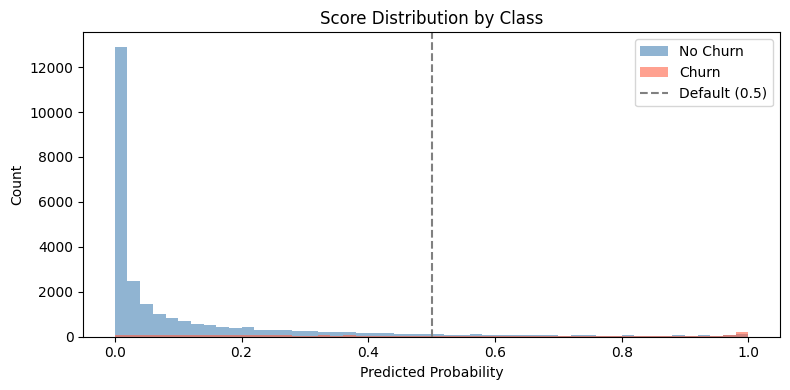

In [29]:
'''PREDICTED PROBABILITIES'''
y_proba = pipeline.predict_proba(x_test)[:, 1]

print("\n=== Probability Score Distribution ===")
print(pd.Series(y_proba).describe())

print(f"\nAvg score — actual churners    : {y_proba[y_test == 1].mean():.4f}")
print(f"Avg score — actual non-churners: {y_proba[y_test == 0].mean():.4f}")

# Histogram of scores by class
plt.figure(figsize=(8, 4))
plt.hist(y_proba[y_test == 0], bins=50, alpha=0.6, label="No Churn", color="steelblue")
plt.hist(y_proba[y_test == 1], bins=50, alpha=0.6, label="Churn",    color="tomato")
plt.axvline(0.5, color="gray", linestyle="--", label="Default (0.5)")
plt.xlabel("Predicted Probability")
plt.ylabel("Count")
plt.title("Score Distribution by Class")
plt.legend()
plt.tight_layout()
plt.show()

[0.0025     0.004      0.005      0.00833333 0.00983333 0.00983333
 0.01       0.015      0.01733333 0.018      0.02       0.025
 0.03       0.035      0.03875    0.04       0.04354545 0.045
 0.05       0.055      0.06       0.06233333 0.06245238 0.06269048
 0.06495238 0.065      0.06833333 0.07       0.07345238 0.075
 0.0775     0.08       0.0819697  0.08245238 0.0825     0.08483333
 0.085      0.09       0.09375    0.0945     0.095      0.09538877
 0.1        0.10233333 0.105      0.10624784 0.10661111 0.11
 0.11333333 0.11363636 0.115      0.119      0.12       0.12208333
 0.12333333 0.125      0.12733333 0.12863636 0.13       0.13029762
 0.13333333 0.135      0.13778355 0.13833333 0.13863636 0.14
 0.14041667 0.14161905 0.14392857 0.14433333 0.145      0.1475
 0.15       0.15261905 0.15441667 0.155      0.15619048 0.15777778
 0.16       0.16333333 0.165      0.17       0.17320413 0.175
 0.17666667 0.18       0.18095238 0.18108333 0.18125    0.18133333
 0.18195238 0.18416667 0.184833

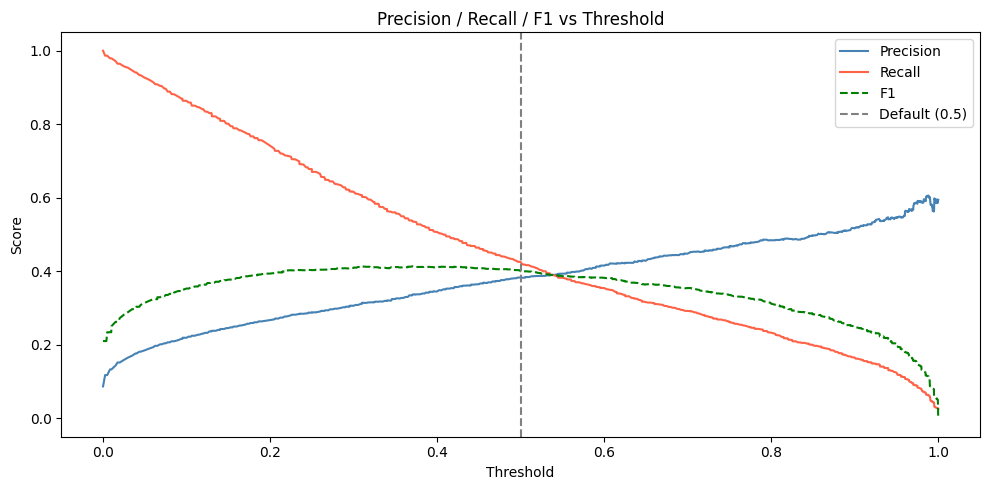

In [44]:
'''THRESHOLD TUNING'''
precision_arr, recall_arr, thresholds = precision_recall_curve(y_test, y_proba)
print (thresholds[1:])
# F1 at each threshold+
f1_arr = (2 * precision_arr[1:] * recall_arr[1:]) / \
         (precision_arr[1:] + recall_arr[1:] + 1e-8)

# Plot Precision / Recall / F1 vs Threshold
plt.figure(figsize=(10, 5))
plt.plot(thresholds, precision_arr[:-1], label="Precision", color="steelblue")
plt.plot(thresholds, recall_arr[:-1],    label="Recall",    color="tomato")
plt.plot(thresholds, f1_arr,             label="F1",        color="green", linestyle="--")
plt.axvline(0.5, color="gray", linestyle="--", label="Default (0.5)")
plt.xlabel("Threshold")
plt.ylabel("Score")
plt.title("Precision / Recall / F1 vs Threshold")
plt.legend()
plt.tight_layout()
plt.show()

In [46]:
# ── Option C : Youden's J (ROC based) ────────────────────────
fpr, tpr, roc_thresh = roc_curve(y_test, y_proba)
youden_j       = tpr - fpr
best_roc_idx   = np.argmax(youden_j)
threshold_roc  = roc_thresh[best_roc_idx]
print(f"\n=== Option C — Youden's J ===")
print(f"Threshold : {threshold_roc:.4f}")
print(f"Recall    : {tpr[best_roc_idx]:.4f}")
print(f"FPR       : {fpr[best_roc_idx]:.4f}")



=== Option C — Youden's J ===
Threshold : 0.1300
Recall    : 0.8302
FPR       : 0.2549


In [50]:
# ──THRESHOLD ─────────────────────────────────
final_threshold = threshold_roc
print(f"\nFinal threshold selected: {final_threshold:.4f}")



Final threshold selected: 0.1300



=== Classification Report @ Threshold 0.1300 ===
              precision    recall  f1-score   support

    No Churn       0.98      0.75      0.85     26446
       Churn       0.24      0.83      0.37      2515

    accuracy                           0.75     28961
   macro avg       0.61      0.79      0.61     28961
weighted avg       0.91      0.75      0.80     28961

ROC-AUC: 0.8596


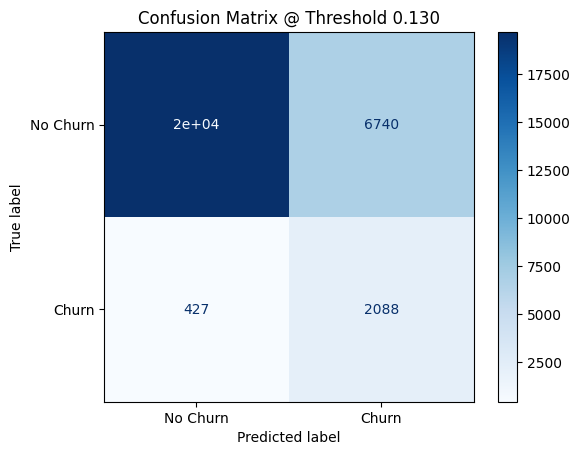

In [57]:
# ── 13. EVALUATE WITH FINAL THRESHOLD ────────────────────────
y_pred_tuned = (y_proba >= final_threshold).astype(int)

print(f"\n=== Classification Report @ Threshold {final_threshold:.4f} ===")
print(classification_report(y_test, y_pred_tuned,
      target_names=["No Churn", "Churn"]))

print(f"ROC-AUC: {roc_auc_score(y_test, y_proba):.4f}")

# Confusion Matrix
ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred_tuned,
    display_labels=["No Churn", "Churn"],
    cmap="Blues"
)
plt.title(f"Confusion Matrix @ Threshold {final_threshold:.3f}")
plt.show()



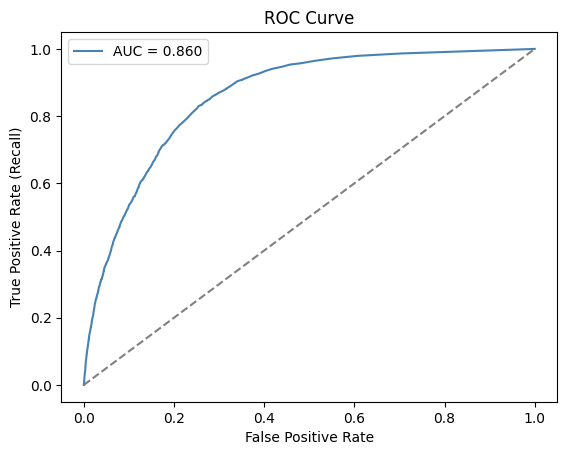

In [58]:
# ROC Curve
plt.figure()
plt.plot(fpr, tpr, label=f"AUC = {roc_auc_score(y_test, y_proba):.3f}",
         color="steelblue")
plt.plot([0, 1], [0, 1], "--", color="gray")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate (Recall)")
plt.title("ROC Curve")
plt.legend()
plt.show()


=== Top 15 Features ===
             Feature  Importance
6       TotalCharges    0.243278
13          Contract    0.153263
12            tenure    0.151675
1     MonthlyCharges    0.144481
11    OnlineSecurity    0.080463
10       TechSupport    0.056488
9       OnlineBackup    0.042656
4      PaymentMethod    0.032968
7            Partner    0.032910
5   DeviceProtection    0.029320
8         Dependents    0.018669
0   PaperlessBilling    0.009860
2      SeniorCitizen    0.003969
3    InternetService    0.000000


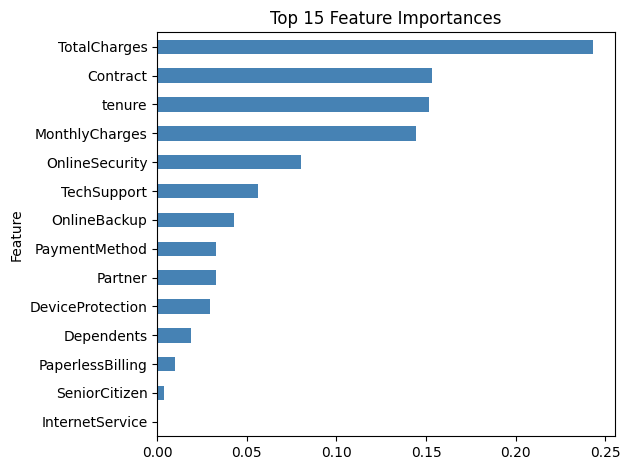

In [59]:
rf_step = pipeline.named_steps["rf"]

importance_df = pd.DataFrame({
    "Feature"   : x_train.columns,
    "Importance": rf_step.feature_importances_
}).sort_values("Importance", ascending=False).head(15)

print("\n=== Top 15 Features ===")
print(importance_df)

importance_df.plot(
    kind="barh", x="Feature", y="Importance",
    title="Top 15 Feature Importances",
    legend=False, color="steelblue"
)
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()


In [60]:
print("\n=== PIPELINE SUMMARY ===")
print(f"Dataset imbalance    : 91.3% / 8.7%  (severe)")
print(f"Resampling           : SMOTE(0.3) + UnderSampler(0.5)")
print(f"Classifier           : RandomForest (n=200, balanced)")
print(f"CV ROC-AUC           : {cv_auc.mean():.4f} ± {cv_auc.std():.4f}")
print(f"Final AUC (test)     : {roc_auc_score(y_test, y_proba):.4f}")
print(f"Threshold used       : {final_threshold:.4f}")


=== PIPELINE SUMMARY ===
Dataset imbalance    : 91.3% / 8.7%  (severe)
Resampling           : SMOTE(0.3) + UnderSampler(0.5)
Classifier           : RandomForest (n=200, balanced)
CV ROC-AUC           : 0.8653 ± 0.0028
Final AUC (test)     : 0.8596
Threshold used       : 0.1300
